In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Load Fashion-MNIST dataset

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Dataset loaded successfully!")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!


In [3]:
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])
print("Image dimensions:", x_train.shape[1:])

Number of training images: 60000
Number of testing images: 10000
Image dimensions: (28, 28)


In [4]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(class_names)

['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


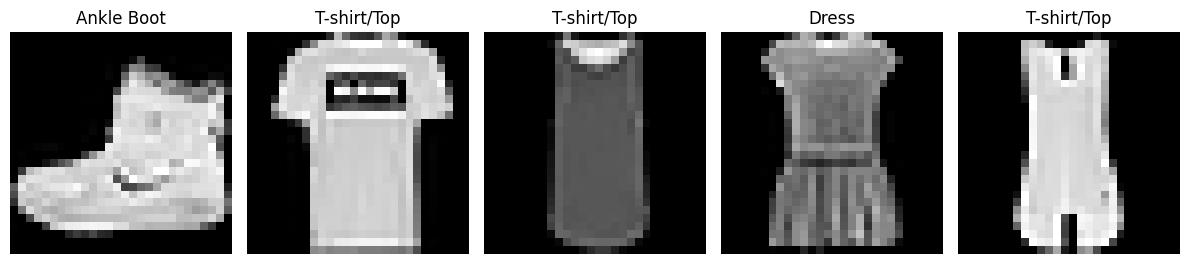

In [5]:
plt.figure(figsize=(12, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Original Fashion-MNIST pixels have values from: 0 to 255

Neural networks generally train better when input values are smaller, so we convert them to: 0 to 1

In [6]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Reshape images for CNN
we have image 28 * 28
expected : height × width × channels
therefore 28 × 28 → 28 × 28 × 1

In [7]:
# Reshape images for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


Building the CNN Model

Lets create the CNN Model

In [8]:
# Create CNN model

model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

    # First Max Pooling Layer
    MaxPooling2D((2, 2)),

    # Second Convolution Layer
    Conv2D(64, (3, 3), activation="relu"),

    # Second Max Pooling Layer
    MaxPooling2D((2, 2)),

    # Flatten
    Flatten(),

    # Dense Hidden Layer
    Dense(128, activation="relu"),

    # Output Layer
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully.")

Model compiled successfully.


Model Training

Train the CNN     
Epochs = 10
Batch size = 64

In [13]:
# Train the CNN

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.8185 - loss: 0.5013 - val_accuracy: 0.8700 - val_loss: 0.3693
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.8805 - loss: 0.3278 - val_accuracy: 0.8892 - val_loss: 0.3035
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.8971 - loss: 0.2793 - val_accuracy: 0.9055 - val_loss: 0.2669
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9079 - loss: 0.2476 - val_accuracy: 0.9012 - val_loss: 0.2643
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.9180 - loss: 0.2233 - val_accuracy: 0.9115 - val_loss: 0.2476
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9254 - loss: 0.1996 - val_accuracy: 0.9142 - val_loss: 0.2361
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9329 - loss: 0.1807 - val_accuracy: 0.9142 - val_loss: 0.2357
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9386 - loss: 0.1645 - 

In [14]:
final_training_accuracy = history.history["accuracy"][-1]

print("Final Training Accuracy:",
      round(final_training_accuracy * 100, 2), "%")

Final Training Accuracy: 95.06 %


training accuracy

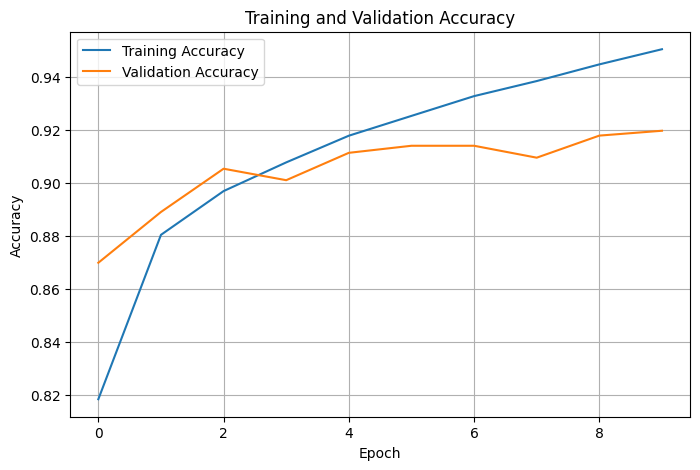

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

 training loss

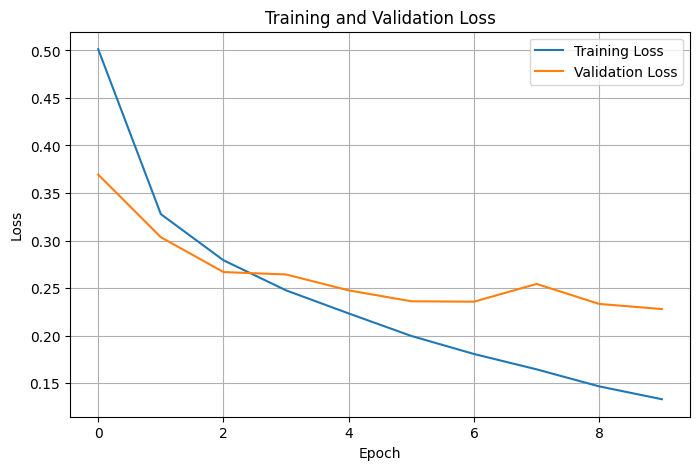

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

Model Evaluation

Evaluate the model on test data

In [17]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9153 - loss: 0.2429
Test Loss: 0.24289360642433167
Test Accuracy: 91.53 %


The CNN outputs probabilities for all 10 classes.

In [18]:
predictions = model.predict(x_test)

print("Prediction shape:", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Prediction shape: (10000, 10)


Now We need to select the class with the highest probability.

In [19]:
y_pred = np.argmax(predictions, axis=1)

print("Predicted labels:")
print(y_pred[:10])

Predicted labels:
[9 2 1 1 6 1 4 6 5 7]


Display 10 test images with predictions

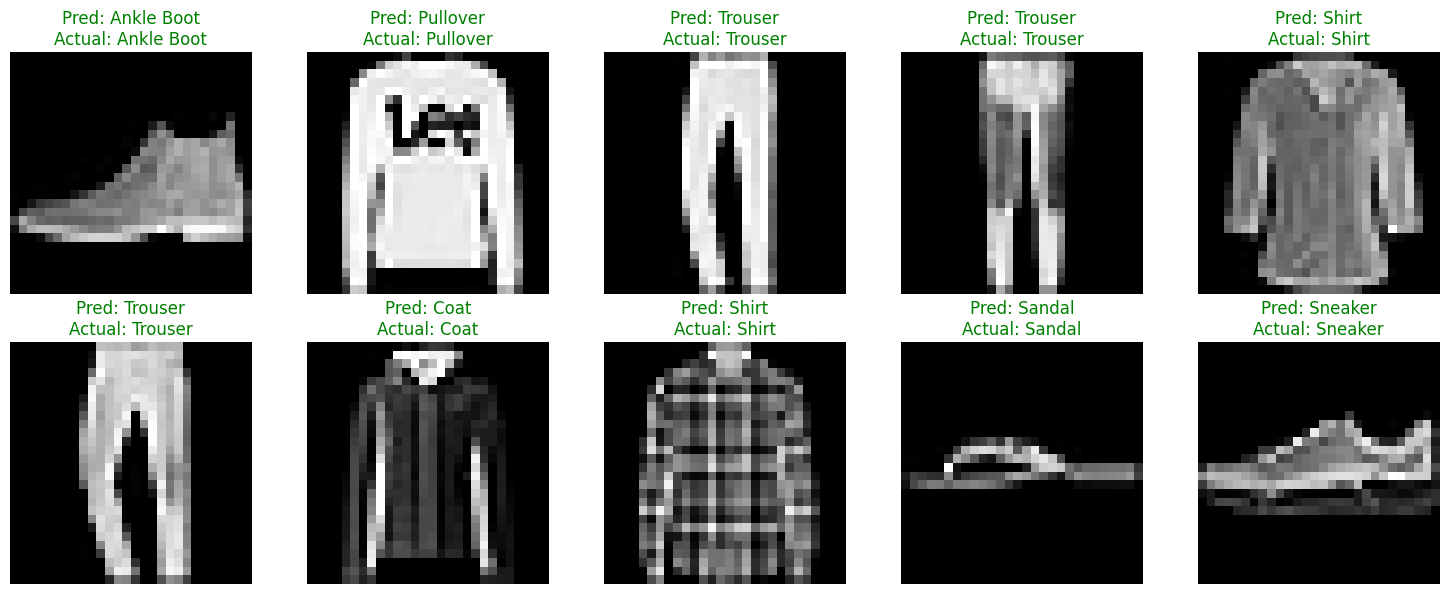

In [20]:
plt.figure(figsize=(15, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    predicted_label = class_names[y_pred[i]]
    actual_label = class_names[y_test[i]]

    color = "green" if y_pred[i] == y_test[i] else "red"

    plt.title(
        f"Pred: {predicted_label}\nActual: {actual_label}",
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Confusion Matrix
for that we need to create the matrix

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[858   0  15  14   4   1 103   0   5   0]
 [  4 976   1  14   2   0   2   0   1   0]
 [ 15   0 876   8  54   0  46   0   1   0]
 [  8   1   6 946   9   0  29   0   1   0]
 [  1   0  41  32 877   0  47   0   2   0]
 [  0   0   0   0   0 984   0  10   0   6]
 [109   0  70  27  64   0 724   1   5   0]
 [  0   0   0   0   0  14   0 962   0  24]
 [  4   0   4   3   2   2   3   3 979   0]
 [  1   0   0   0   0   3   0  25   0 971]]


The confusion matrix shows which classes are being confused with each other

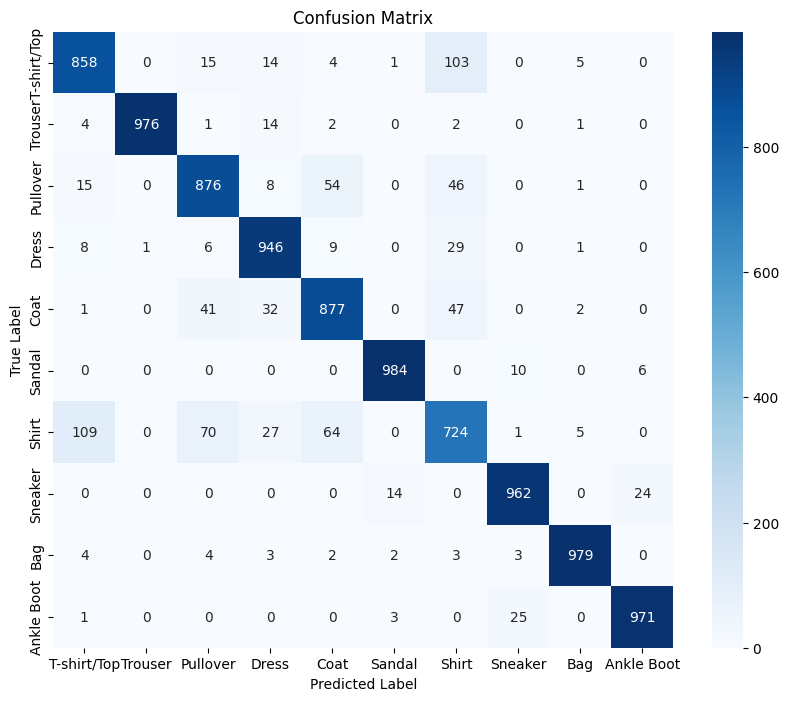

In [22]:
# Now visualize it:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

 Report Classification

In [23]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

 T-shirt/Top       0.86      0.86      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.86      0.88      0.87      1000
       Dress       0.91      0.95      0.93      1000
        Coat       0.87      0.88      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.72      0.74      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.91      0.92      0.92     10000
weighted avg       0.91      0.92      0.92     10000



 Part 5 — Model Analysis
Answer the following questions:
1. Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image
classification?

==> CNNs are better for image classification because they are specially designed to work with images.

CNNs keep the image structure, while ANNs usually convert the image into a single long list of pixels.
CNNs can detect important features like edges, shapes, colors, and patterns.
CNNs use fewer parameters, so they need less memory and can train faster.
CNNs can understand the relationship between nearby pixels in an image.

2. What is the purpose of a Convolution Layer?

==> A convolution layer helps the CNN find important features in an image.

It uses small filters to scan the image.
These filters can find features like edges, lines, shapes, and textures.
The detected features are passed to the next layers.
The network uses these features to understand and classify the image.

3. Why is Max Pooling used in CNNs?

==> Max Pooling is used to reduce the spatial dimensions of feature maps while retaining the most important information.

For example, a 2×2 max-pooling operation selects the largest value from each 2×2 region. This reduces the size of the feature map and therefore decreases the computational requirements of the network.

Max Pooling also helps the model become less sensitive to small changes in the position of features and can help reduce overfitting.

4. Why is the Flatten Layer Required Before Dense Layers?

==> The convolution and pooling layers produce feature maps in a three-dimensional format consisting of height, width, and channels.

Dense layers, however, expect a one-dimensional input vector.

The Flatten layer converts the three-dimensional feature maps into a one-dimensional vector so that the extracted features can be passed to the fully connected Dense layers for classification.

5. Why is the Softmax Activation Function Used in the Output Layer?

==> Softmax is used in the output layer because this assignment involves multi-class classification with 10 different classes.

Softmax converts the output values into probabilities whose total sum is approximately 1. Each output represents the probability that the image belongs to a particular class.

The class with the highest probability is selected as the predicted class.

For example, the model may produce:

T-shirt: 0.05
Trouser: 0.02
Sneaker: 0.90
Bag: 0.01

In this example, the model predicts Sneaker because it has the highest probability.

6. How Does the Adam Optimizer Help in Training the CNN?

==> Adam stands for Adaptive Moment Estimation. It is an optimization algorithm used to update the weights of the neural network during training.

Adam combines ideas from momentum-based optimization and adaptive learning rates. It automatically adjusts the learning rate for different model parameters based on the gradients observed during training.

This generally allows the CNN to converge faster and makes training more stable compared with using a fixed learning rate.

Therefore, Adam is a popular choice for training CNNs because it provides efficient and adaptive weight updates.

